# Classically Punk

# todo:
* for visualizations:
  * T-SNE - better from PCA
  * Umap - better than T-SNe - https://pair-code.github.io/understanding-umap/

The genres data can be found on Kaggle: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [2]:
import librosa 
import IPython.display as ipd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn as nn
import umap
import plotly.express as px

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

%matplotlib inline

## Data Exploration

In [2]:
genres = ["rock", "blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae"]

I will explore how each genre looks like as a wave to familarize my self.

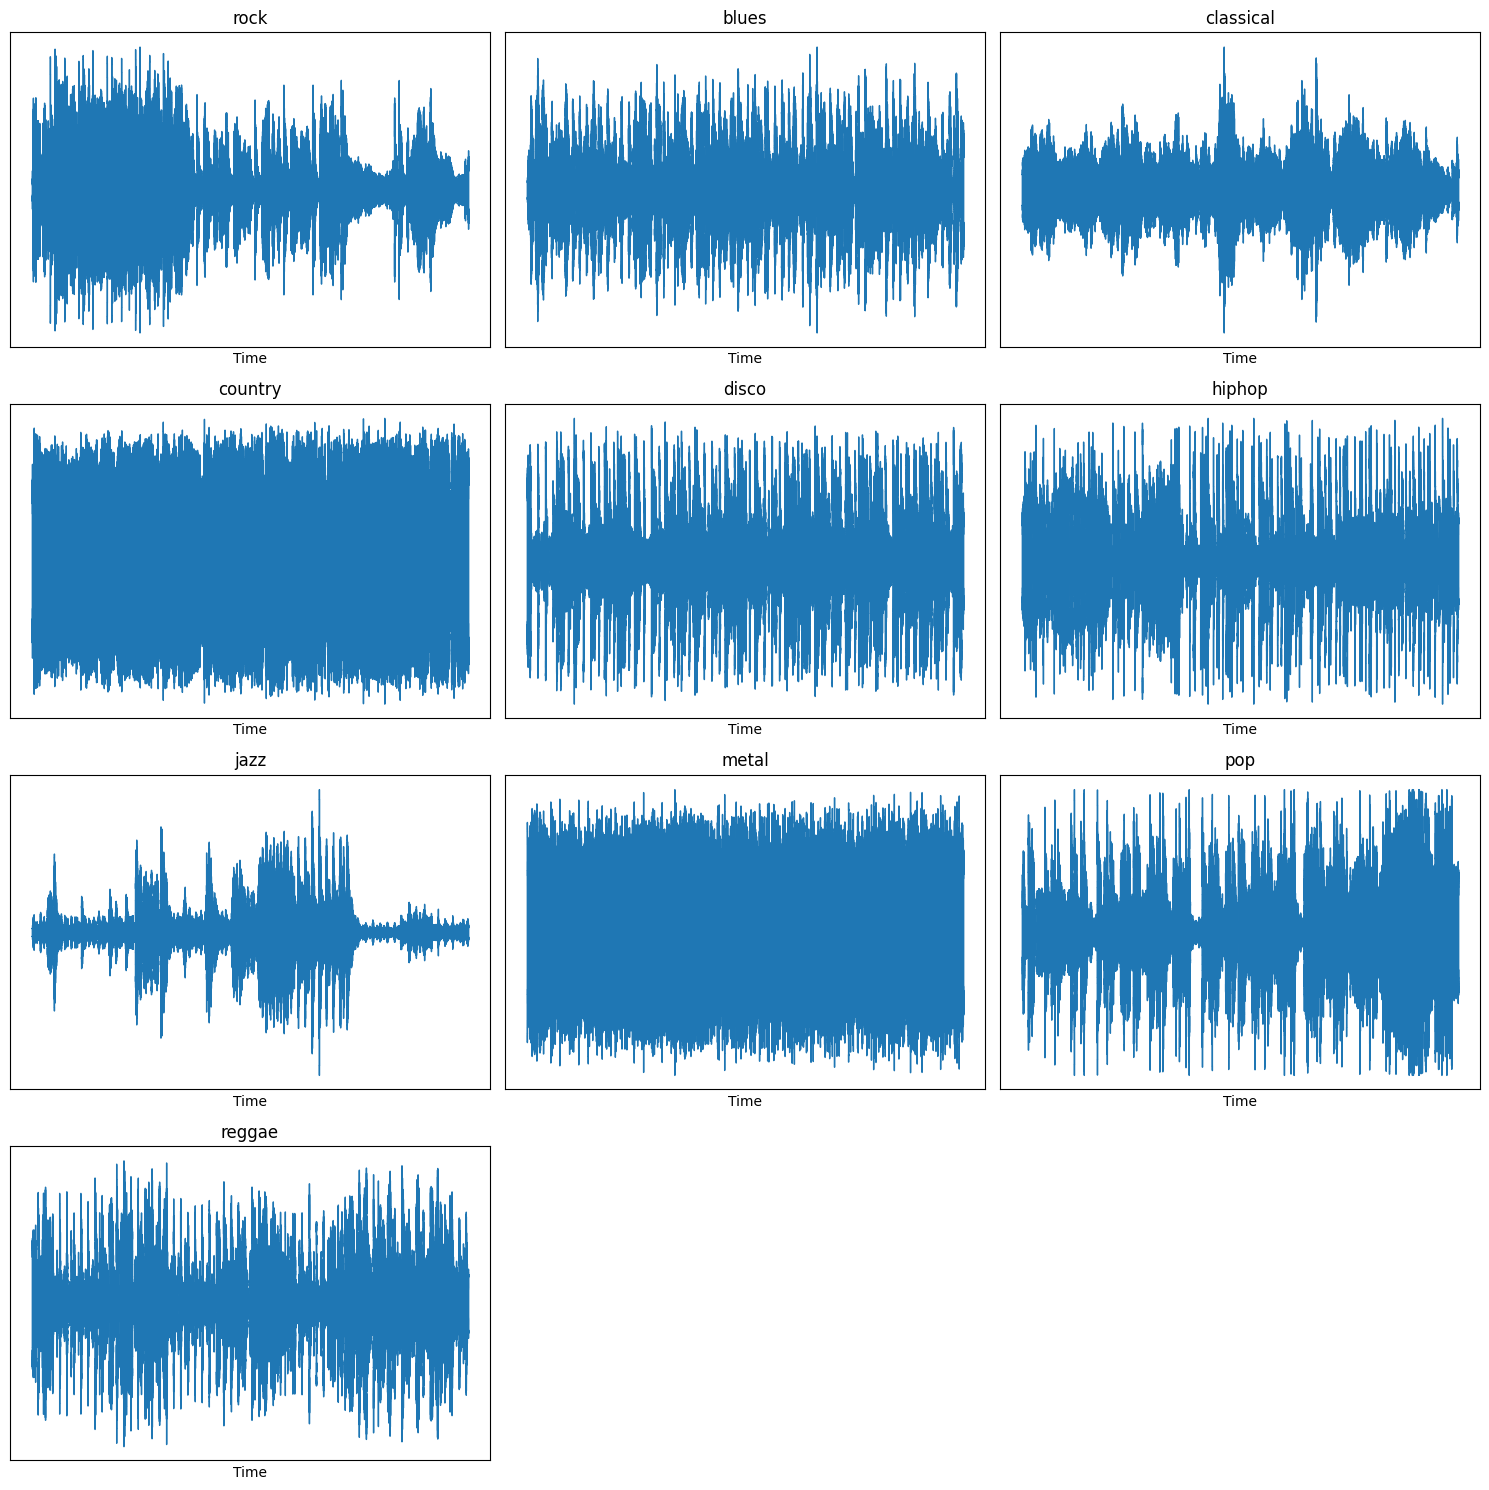

In [3]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for idx, genre in enumerate(genres):
    audio_path = f'genres/{genre}/{genre}.00000.wav'
    x, sr = librosa.load(audio_path)
    librosa.display.waveshow(x, sr=sr, ax=axs[idx])
    axs[idx].set_title(genre)
    axs[idx].set_xticks([])
    axs[idx].set_yticks([])

for ax in axs[10:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

Now, I will explore how each genre looks like as a spectrogram again to familarize my self.

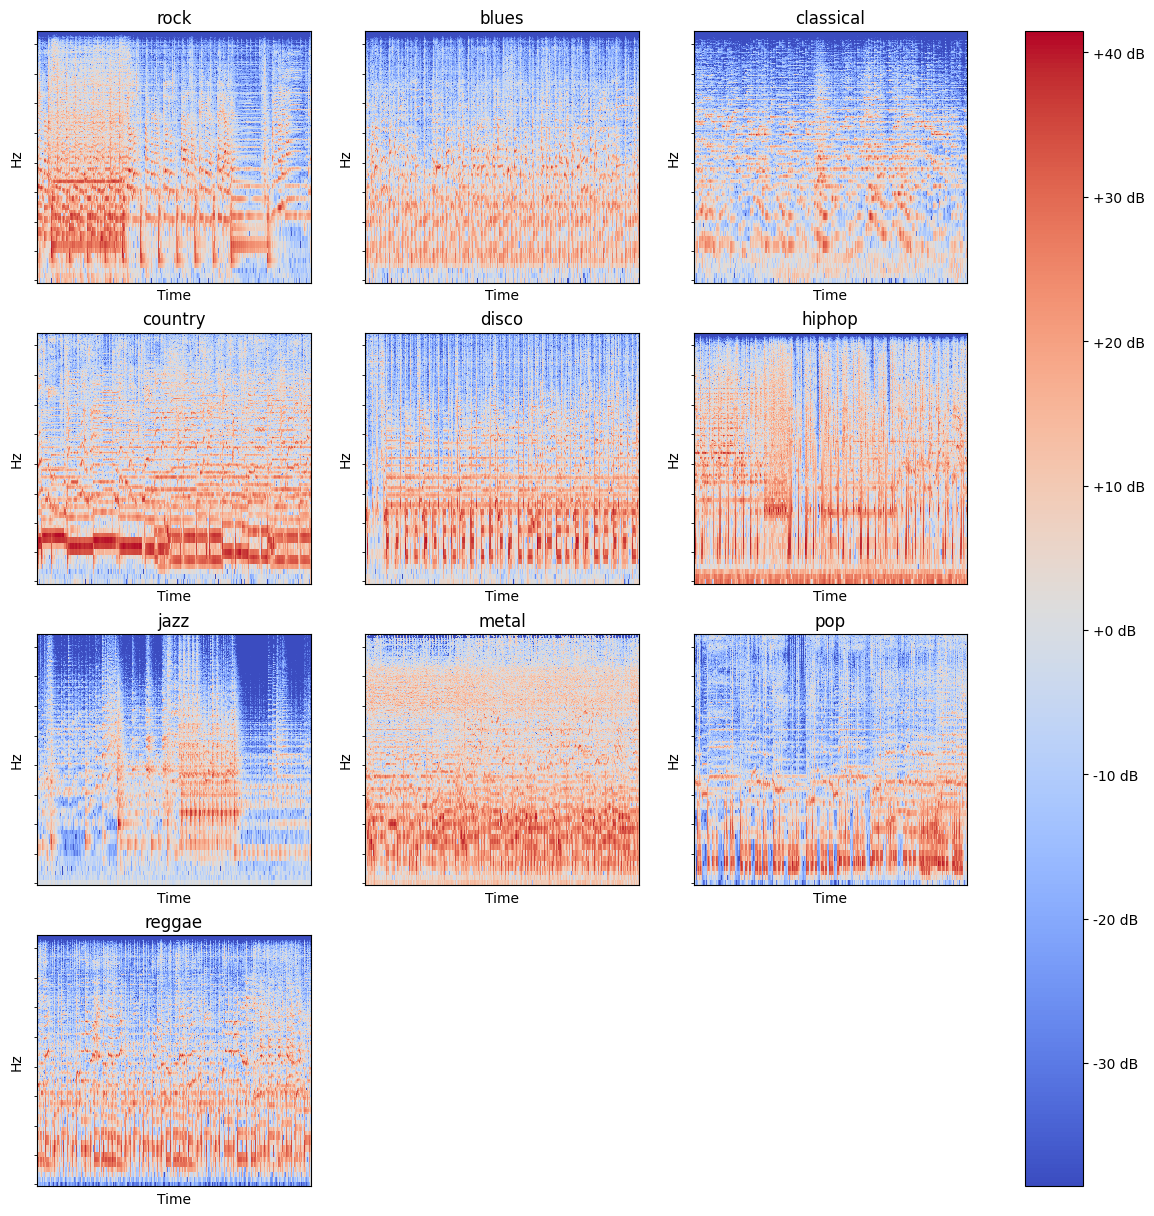

In [4]:
fig, axs = plt.subplots(4, 3, figsize=(15, 15))
axs = axs.flatten()

for idx, genre in enumerate(genres):
    audio_path = f'genres/{genre}/{genre}.00000.wav'
    x, sr = librosa.load(audio_path)
    X = librosa.stft(x)
    Xdb = librosa.amplitude_to_db(abs(X))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log', ax=axs[idx])
    axs[idx].set_title(genre)
    axs[idx].set_xticks([])
    axs[idx].set_yticks([])

for ax in axs[10:]:
    ax.axis("off")
    
fig.colorbar(img, ax=axs, format="%+2.f dB")

plt.show()

## Feature extraction

* Feature 1 - Zero Crossings - The zero-crossing rate is the rate of sign-changes along with a signal, i.e., the rate at which the signal changes from positive to negative or back.
* Feature 2 - Spectral Centroids - It indicates where the " center of mass" for a sound is located and is calculated as the weighted mean of the frequencies present in the sound.
* Feature 3 - Spectral Rolloff - It is a measure of the shape of the signal. It represents the frequency below which a specified percentage of the total spectral energy, e.g., 85%, lies.
* Feature 4 - MFCCs - The Mel frequency cepstral coefficients (MFCCs) of a signal are a small set of features (usually about 10–20) that concisely describe the overall shape of a spectral envelope.
* Feature 5 - Chroma Frequencies - Chroma features are an interesting and powerful representation for music audio in which the entire spectrum is projected onto 12 bins representing the 12 distinct semitones (or chroma) of the musical octave.


In [5]:
def feature_extract(x, sr):
    raw_features = {}
    raw_features["zero_crossings"] = librosa.zero_crossings(x, pad=False)
    raw_features["spectral_centroids"] = librosa.feature.spectral_centroid(y=x, sr=sr)[0]
    raw_features["spectral_rolloff"] = librosa.feature.spectral_rolloff(y=x+0.01, sr=sr)[0]
    raw_features["mfccs"] = librosa.feature.mfcc(y=x, sr=sr)
    hop_length = 512
    raw_features["chromagram"] = librosa.feature.chroma_stft(y=x, sr=sr, hop_length=hop_length)
    raw_features["duration"] = librosa.get_duration(y=x, sr=sr)
    return raw_features

In [8]:
def generate_df(raw_features):
    new_df = pd.DataFrame()
    new_df["duration"] = [raw_features["duration"]]
    new_df["zero_crossing_rate_mean"] = [np.mean(raw_features["zero_crossings"])]
    new_df["zero_crossing_rate_var"] = [np.var(raw_features["zero_crossings"])]
    new_df["chroma_stft_mean"] = [np.mean(raw_features["chromagram"])]
    new_df["chroma_stft_var"] = [np.var(raw_features["chromagram"])]
    new_df["spectral_centroid_mean"] = [np.mean(raw_features["spectral_centroids"])]
    new_df["spectral_centroid_var"] = [np.var(raw_features["spectral_centroids"])]
    new_df["spectral_rolloff_mean"] = [np.mean(raw_features["spectral_rolloff"])]
    new_df["spectral_rolloff_var"] = [np.var(raw_features["spectral_rolloff"])]

    mfccs = raw_features["mfccs"]
    mfccs_means = np.mean(mfccs, axis=1)   
    mfccs_vars = np.var(mfccs, axis=1)
    
    for i in range(len(mfccs_means)):
        new_df[f"mfcc{i+1}_mean"] = mfccs_means[i]
        new_df[f"mfcc{i+1}_var"] = mfccs_vars[i]
        
    return new_df

In [9]:
df = pd.DataFrame()

for genre in genres:
    pathlist = Path(f"genres/{genre}").glob('**/*.wav')
    for path in pathlist:
        audio_path = str(path)   
        x, sr = librosa.load(audio_path)
        raw_features = feature_extract(x, sr)
        new_df = generate_df(raw_features)
        new_df["audio_path"] = [audio_path]
        new_df["genre"] = [genre]
        df = pd.concat([df, new_df])


In [10]:
df.head(10)

,duration,zero_crossing_rate_mean,zero_crossing_rate_var,chroma_stft_mean,chroma_stft_var,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,mfcc1_mean,...,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,audio_path,genre
0,30.013333,0.054419,0.051457,0.343304,0.088840,1537.468449,491539.222968,3365.632987,2.399023e+06,-169.683121,...,-4.370689,71.076286,1.172074,96.772148,0.487476,79.974068,-5.829065,75.677567,genres/rock/rock.00011.wav,rock
0,30.013333,0.077137,0.071187,0.376758,0.081911,1542.109295,112771.940438,2856.346920,6.326828e+05,-62.364849,...,-2.277512,27.141008,-5.244769,41.878750,-5.225095,28.841183,-6.276886,33.442474,genres/rock/rock.00005.wav,rock
0,30.013333,0.122933,0.107820,0.442637,0.072727,2559.166385,237199.771519,5405.908146,1.833627e+06,-50.849358,...,-1.575925,17.213970,-3.856851,19.390163,-6.144731,18.558167,-5.379481,17.193031,genres/rock/rock.00039.wav,rock
0,29.995828,0.140760,0.120947,0.411478,0.084623,2794.963092,337551.767364,5848.522968,1.571478e+06,-15.928070,...,-1.577643,55.314949,1.581098,47.192097,0.412815,72.592552,2.938724,49.908951,genres/rock/rock.00038.wav,rock
0,30.013333,0.041146,0.039453,0.371823,0.088695,1345.841383,476337.645336,2909.497127,2.559444e+06,-127.970406,...,-5.323316,46.326420,-0.843005,43.065781,-4.661474,27.124546,-4.788684,27.636402,genres/rock/rock.00004.wav,rock
0,30.013333,0.071824,0.066666,0.398271,0.087783,1857.972599,379959.172087,4157.506956,1.664719e+06,-108.948036,...,-11.798590,45.530430,-6.499074,39.328686,-4.303898,48.186462,-2.736336,33.109138,genres/rock/rock.00010.wav,rock
0,30.013333,0.087446,0.079799,0.344484,0.088035,1676.146048,209843.569368,3235.825909,7.310830e+05,-98.386490,...,-8.629558,65.665977,-1.890370,52.954563,-2.185492,41.101078,-3.397589,44.949505,genres/rock/rock.00006.wav,rock
0,30.013333,0.068363,0.063689,0.338949,0.098358,1863.764472,812510.114355,3920.150438,2.787029e+06,-204.604706,...,-9.628987,57.548325,-7.385819,55.118099,-9.435307,38.829109,-3.133871,46.775032,genres/rock/rock.00012.wav,rock
0,30.013333,0.046173,0.044041,0.440252,0.092675,1597.518016,704726.779147,3765.779188,4.573432e+06,-211.216751,...,-6.636384,81.413345,-1.277511,97.177780,2.781899,106.339111,6.266782,77.187325,genres/rock/rock.00013.wav,rock
0,30.013333,0.047244,0.045012,0.359125,0.087730,1282.197334,299724.661206,2643.704457,1.624868e+06,-140.464172,...,-6.488681,53.077278,-4.709777,49.610229,-2.570159,34.243237,-1.791593,28.876339,genres/rock/rock.00007.wav,rock


In [11]:
df.shape

(1000, 51)

In [12]:
df.describe()

,duration,zero_crossing_rate_mean,zero_crossing_rate_var,chroma_stft_mean,chroma_stft_var,spectral_centroid_mean,spectral_centroid_var,spectral_rolloff_mean,spectral_rolloff_var,mfcc1_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1.000000e+03,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,30.024075,0.103768,0.091248,0.378719,0.086345,2201.887215,4.695929e+05,4510.385149,1.839928e+06,-144.497314,...,1.148273,60.714851,-3.967269,62.614868,0.507468,63.695969,-2.329926,66.211205,-1.095509,70.110397
std,0.080910,0.041886,0.032323,0.081704,0.007739,715.916104,4.007595e+05,1611.363501,1.431312e+06,100.218719,...,4.579028,33.784050,4.549767,33.469387,3.869681,34.388195,3.755824,37.166142,3.837095,45.233253
min,29.931973,0.021727,0.021255,0.171896,0.044571,570.349904,7.996725e+03,647.286754,1.269754e+04,-552.158630,...,-15.693879,9.200758,-17.237364,13.870571,-11.981186,15.401894,-18.505384,13.417371,-19.928354,7.871336
25%,30.000181,0.070332,0.065385,0.319612,0.082358,1627.911508,1.845128e+05,3332.215304,7.628167e+05,-200.773685,...,-1.863282,40.335190,-7.205973,40.807056,-2.004486,41.860617,-4.666947,41.714985,-3.367671,42.308999
50%,30.013333,0.099613,0.089691,0.383192,0.086616,2209.334372,3.384935e+05,4611.777604,1.458371e+06,-120.327309,...,1.215503,52.256985,-4.070210,54.757240,0.670040,54.753153,-2.393430,57.425217,-1.164691,59.157099
75%,30.013333,0.132133,0.114674,0.435652,0.091259,2691.335270,6.121681e+05,5503.575711,2.543377e+06,-73.962498,...,4.365737,71.447191,-0.845321,75.036001,3.117758,75.401909,0.151603,78.552641,1.305560,85.292044
max,30.648889,0.274987,0.199369,0.663652,0.108057,4435.732059,3.033959e+06,8664.824377,8.723025e+06,42.091446,...,13.465460,393.005707,11.470961,405.928711,15.394898,332.782013,14.700517,393.373779,15.361670,506.306854


In [13]:
df.to_csv("audio_data.csv", index=False)

## Dataset preprocessing

In [172]:
df = pd.read_csv("audio_data.csv")

In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   duration                 1000 non-null   float64
 1   zero_crossing_rate_mean  1000 non-null   float64
 2   zero_crossing_rate_var   1000 non-null   float64
 3   chroma_stft_mean         1000 non-null   float64
 4   chroma_stft_var          1000 non-null   float64
 5   spectral_centroid_mean   1000 non-null   float64
 6   spectral_centroid_var    1000 non-null   float64
 7   spectral_rolloff_mean    1000 non-null   float64
 8   spectral_rolloff_var     1000 non-null   float64
 9   mfcc1_mean               1000 non-null   float64
 10  mfcc1_var                1000 non-null   float64
 11  mfcc2_mean               1000 non-null   float64
 12  mfcc2_var                1000 non-null   float64
 13  mfcc3_mean               1000 non-null   float64
 14  mfcc3_var                

First of all, I need to encode the categorical target to be able to train a model.

In [174]:
encoder = LabelEncoder()
y = encoder.fit_transform(df["genre"])
y

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9,
       9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2,

In [175]:
X = df.drop(columns=["genre", "audio_path"])

After, I have encoded the data, it is time for train/test/validation split.

In [176]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=1)

In [177]:
X_train.shape, X_val.shape, X_test.shape

((600, 49), (200, 49), (200, 49))

Next, I have to standardize the rest features. I will be utilizing the RobustScaler. I have tried StandardScaler and MinMaxScaler but they were much worse, StandardScaler was around 0.07 worse than RobustScaler and the MinMaxScaler was even worse with difference more than 20% compared to the RobustScaler.

In [178]:
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

In [179]:
X_val

array([[ 0.        ,  1.87863728,  1.6198703 , ...,  0.09381877,
        -0.64188112,  0.30115083],
       [ 0.        , -0.37789995, -0.39073557, ...,  0.18986669,
        -0.33102434,  0.09617946],
       [ 0.        ,  0.47695483,  0.4621296 , ..., -0.1422869 ,
         0.8925752 , -0.45704195],
       ...,
       [-2.39310345,  0.24100067,  0.23783668, ...,  0.1481119 ,
        -0.24127571,  0.12468941],
       [ 0.        , -0.6546819 , -0.69070704, ...,  6.87081589,
         2.37275935, 11.12447071],
       [ 0.        ,  0.1453882 ,  0.14453724, ..., -0.04669353,
        -0.64005041, -0.24209303]], shape=(200, 49))

## Model Building

In [180]:
# Baseline model for comparison
classifier = LogisticRegression()
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.71      0.62        21
           1       0.86      0.95      0.90        20
           2       0.33      0.31      0.32        13
           3       0.58      0.64      0.61        22
           4       0.75      0.75      0.75        28
           5       0.72      0.65      0.68        20
           6       0.85      0.85      0.85        20
           7       0.89      1.00      0.94        17
           8       0.78      0.74      0.76        19
           9       0.50      0.30      0.38        20

    accuracy                           0.70       200
   macro avg       0.68      0.69      0.68       200
weighted avg       0.69      0.70      0.69       200



/Users/nikolaykirilov/Documents/University/qwasar/classically_punk/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Baseline:**
* Precision: 0.69
* Recall: 0.70
* Accuracy: 0.70
* F1 Score: 0.70

In [73]:
# T-SNE - better from PCA
# Umap - better than T-SNe

In [74]:
X_train.shape, X_test.shape

((600, 49), (200, 49))

In [12]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train)  # Shape: (600, 2)

In [13]:
def plot_predictions(train_data, train_label, test_data, test_labels, predictions=None):
    """
    Plots trainging data, test data and compares predictions.
    """
    plt.figure(figsize=(9, 6))
    
    pca = PCA(n_components=2)
    
    X_train_reduced = pca.fit_transform(train_data) 
    X_test_reduced = pca.fit_transform(test_data) 
    
    # plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c='blue', label="Traing data", alpha=0.6)
    # plt.scatter(X_test_reduced[:,0], X_test_reduced[:,1], c='red', label="Testing data", alpha=0.6)

    plt.scatter(X_train_reduced[:,0], X_train_reduced[:,1], c=train_label, cmap='viridis', label='Train', alpha=0.8)
    plt.scatter(X_test_reduced[:,0], X_test_reduced[:,1], c=test_labels, cmap='plasma', label='Test', alpha=0.8)

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('Traing data')
    plt.title('Training vs Testing data (PCA 2D)')

    if predictions is not None:
        plt.scatter(X_test_reduced[:,0], X_test_reduced[:,1], c=predictions, cmap='coolwarm', marker='x', label='Test (pred)', alpha=0.8)

    plt.legend(prop={"size": 14})
    plt.show()

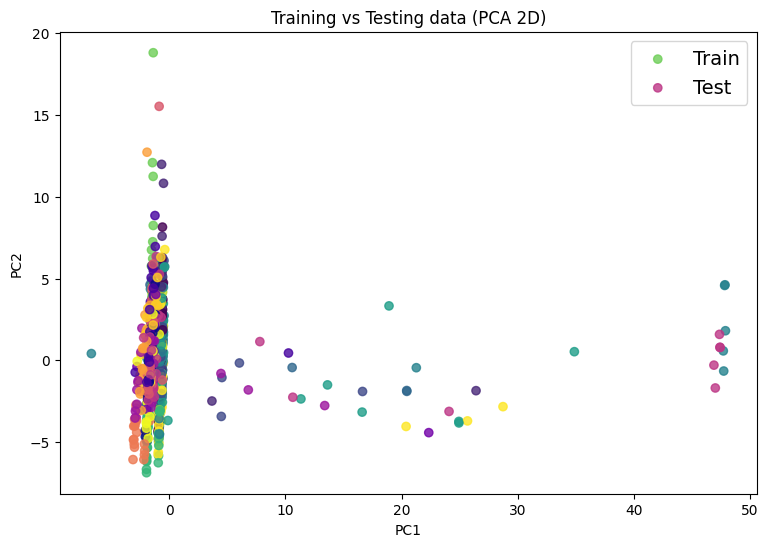

In [14]:
plot_predictions(X_train, y_train, X_test, y_test)

In [280]:
class AudioFeaturesDataset(Dataset):
    def __init__(self, X, y, features):
        self.feature_columns = features
        self.X = X.astype('float32')
        self.y = y.astype('float32')

        self.X = torch.tensor(self.X, dtype=torch.float32)
        self.y = torch.tensor(self.y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [281]:
features = df.drop(columns=["audio_path", "genre"]).columns
train_dataset = AudioFeaturesDataset(X_train, y_train, features)
test_dataset = AudioFeaturesDataset(X_test, y_test, features) 
val_dataset = AudioFeaturesDataset(X_val, y_val, features) 

In [282]:
num_features = len(features)  # number of columns in your features
num_classes = 10  # change to your number of genres

class AudioFCClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.5),

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),
            
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = AudioFCClassifier(num_features, num_classes)

In [283]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16)
val_dataloader = DataLoader(val_dataset, batch_size=16)

In [284]:
epochs = 401

# Track different values
epoch_count = []
loss_values = []
test_loss_values = []

patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.05, patience=10
)

for epoch in range(epochs):
    ### Training
    model.train()
    
    for train_batch in train_dataloader:
        x_tr, y_tr = train_batch
        
        # 1. Forward pass (propagation)
        y_pr = model(x_tr)
    
        # 2. Calculate the loss
        loss = loss_fn(y_pr, y_tr)
        
        # 3. Optimizer zero grad
        optimizer.zero_grad()
    
        # 4. Perform backpropagation
        loss.backward()
    
        # 5. Step the optimizer
        optimizer.step()
        loss_values.append(loss.detach().cpu())
        
    ### Testing
    model.eval()
    test_loss = 0.0
    with torch.inference_mode():
        for test_batch in test_dataloader:
            x_t, y_t = test_batch
            test_pred = model(x_t)
            test_loss = loss_fn(test_pred, y_t)
            test_loss_values.append(test_loss.detach().cpu())

    mean_test_loss = float(torch.mean(torch.stack(test_loss_values)))

    if mean_test_loss < best_val_loss:
        best_val_loss = mean_test_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt") 
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

    if epoch % 100 == 0:
        epoch_count.append(epoch)
        print(f"Epoch: {epoch}, Train Loss: {loss}, Mean Loss: {np.mean(loss_values)}, "
              f"Test Loss: {test_loss}, Mean Test Loss: {np.mean(test_loss_values)}")

    scheduler.step(test_loss)


Epoch: 0, Train Loss: 1.7864786386489868, Mean Loss: 2.0405046939849854, Test Loss: 1.391984462738037, Mean Test Loss: 1.5534106492996216
Epoch: 100, Train Loss: 2.2124977111816406, Mean Loss: 0.7275604605674744, Test Loss: 0.39569783210754395, Mean Test Loss: 0.7703909277915955
Epoch: 200, Train Loss: 1.2304924726486206, Mean Loss: 0.6325764656066895, Test Loss: 0.31460726261138916, Mean Test Loss: 0.7278085350990295
Epoch: 300, Train Loss: 0.26700252294540405, Mean Loss: 0.6007267236709595, Test Loss: 0.376780241727829, Mean Test Loss: 0.7140228152275085
Epoch: 400, Train Loss: 0.8933376669883728, Mean Loss: 0.5829904675483704, Test Loss: 0.3447955548763275, Mean Test Loss: 0.7072975635528564


In [285]:
# regularization for the model
# try smaller model


In [286]:
def smooth_curve(values, smoothing_factor=0.9):
    """
    Applies exponential moving average smoothing to a sequence.
    
    Args:
        values (list or np.ndarray): Input loss values.
        smoothing_factor (float): Between 0 and 1. Higher = smoother curve.
    """
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * smoothing_factor + (1 - smoothing_factor) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return np.array(smoothed)


def plot_train_test_losses(train_losses, test_losses, title="Training vs Testing Loss",
                           smooth=True, smoothing_factor=0.9):
    """
    Visualizes (optionally smoothed) training and testing loss curves with different lengths.

    Args:
        train_losses (list): Training loss values.
        test_losses (list): Testing loss values.
        title (str): Plot title.
        smooth (bool): Whether to smooth the curves.
        smoothing_factor (float): Smoothing factor for EMA (0–1). Higher = smoother.
    """
    train_losses = np.array(train_losses)
    test_losses = np.array(test_losses)

    # Apply smoothing
    if smooth:
        train_losses = smooth_curve(train_losses, smoothing_factor)
        test_losses = smooth_curve(test_losses, smoothing_factor)

    # Normalize x-axis (0–1 scale)
    x_train = np.linspace(0, 1, len(train_losses))
    x_test = np.linspace(0, 1, len(test_losses))

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(x_train, train_losses, label="Training Loss", alpha=0.8)
    plt.plot(x_test, test_losses, label="Testing Loss", alpha=0.8)
    plt.title(title, fontsize=14)
    plt.xlabel("Normalized Progress", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

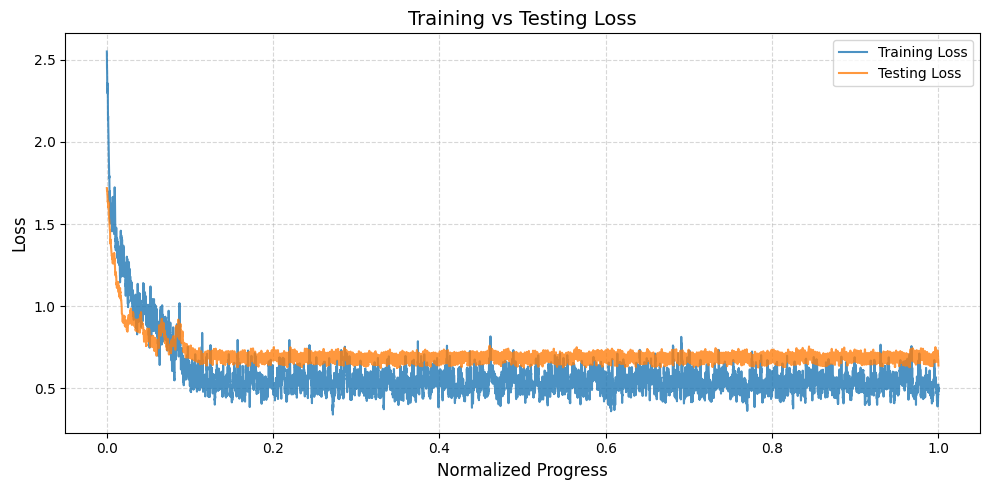

In [287]:
plot_train_test_losses(loss_values, test_loss_values)

In [288]:
y_preds = []
y_tests = []

model.eval() 
with torch.inference_mode():
    for test_batch in val_dataloader:
        x_t, y_t = test_batch
        
        test_pred = model(x_t)

        test_loss = loss_fn(test_pred, y_t)
        softmax = nn.functional.softmax(test_pred, dim=1)
        
        y_pr = torch.argmax(softmax, dim=1)
        y_preds.append(y_pr)
        y_tests.append(y_t)
        
    print(classification_report(torch.concatenate(y_tests), torch.concatenate(y_preds)))
        

              precision    recall  f1-score   support

           0       0.81      0.85      0.83        20
           1       0.95      0.75      0.84        24
           2       0.68      0.72      0.70        18
           3       0.85      0.81      0.83        21
           4       0.53      0.62      0.57        13
           5       0.76      0.89      0.82        18
           6       0.94      0.85      0.89        20
           7       0.68      0.94      0.79        18
           8       0.80      0.64      0.71        25
           9       0.73      0.70      0.71        23

    accuracy                           0.78       200
   macro avg       0.77      0.78      0.77       200
weighted avg       0.79      0.78      0.78       200



In [289]:
y_preds = []
y_tests = []

model.eval() 
with torch.inference_mode():
    for test_batch in train_dataloader:
        x_t, y_t = test_batch
        
        test_pred = model(x_t)

        test_loss = loss_fn(test_pred, y_t)
        softmax = nn.functional.softmax(test_pred, dim=1)
        
        y_pr = torch.argmax(softmax, dim=1)
        y_preds.append(y_pr)
        y_tests.append(y_t)
        
    print(classification_report(torch.concatenate(y_tests), torch.concatenate(y_preds)))
        

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        59
           1       0.98      1.00      0.99        56
           2       1.00      0.97      0.99        69
           3       0.95      0.93      0.94        57
           4       0.97      0.95      0.96        59
           5       0.98      1.00      0.99        62
           6       0.98      0.98      0.98        60
           7       0.94      1.00      0.97        65
           8       1.00      0.98      0.99        56
           9       0.95      0.93      0.94        57

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600



In [269]:
len(y_preds), len(y_tests)

(38, 38)

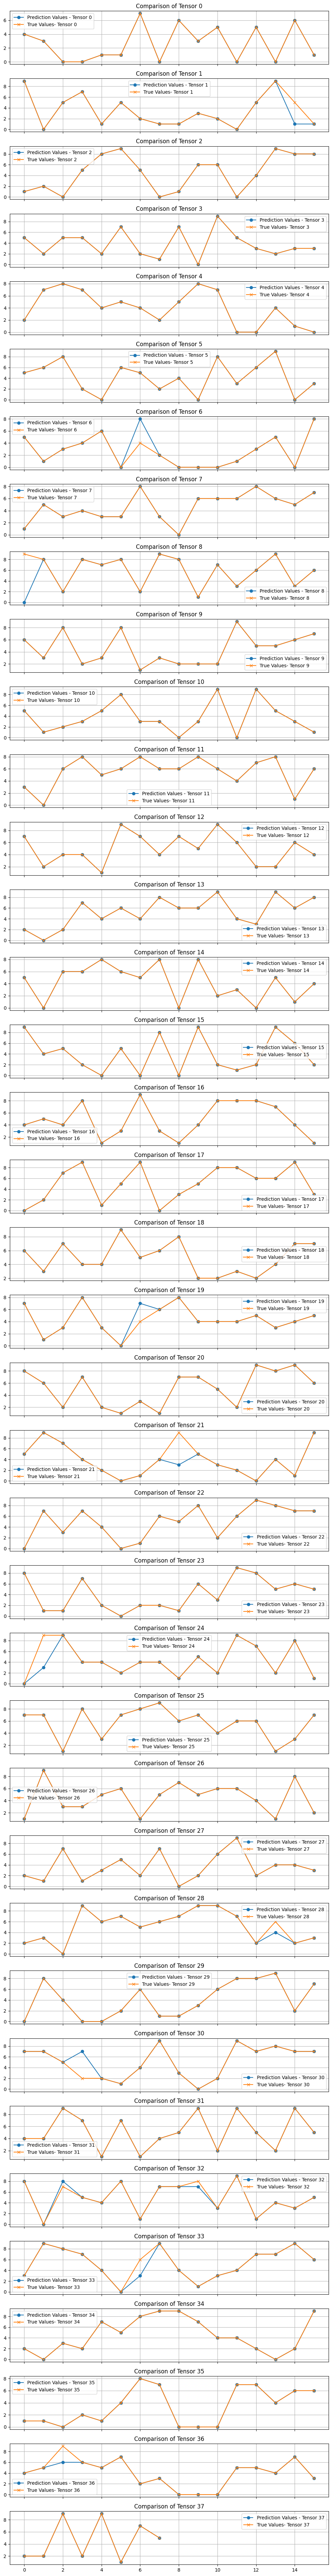

In [258]:
num_pairs = min(len(y_preds), len(y_tests))
fig, axes = plt.subplots(num_pairs, 1, figsize=(10, 2*num_pairs), sharex=True)

if num_pairs == 1:
    axes = [axes]

for i in range(num_pairs):
    x1 = y_preds[i].numpy()
    x2 = y_tests[i].numpy()
    axes[i].plot(x1, label=f"Prediction Values - Tensor {i}", marker="o")
    axes[i].plot(x2, label=f"True Values- Tensor {i}", marker="x")
    axes[i].legend()
    axes[i].set_title(f"Comparison of Tensor {i}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()